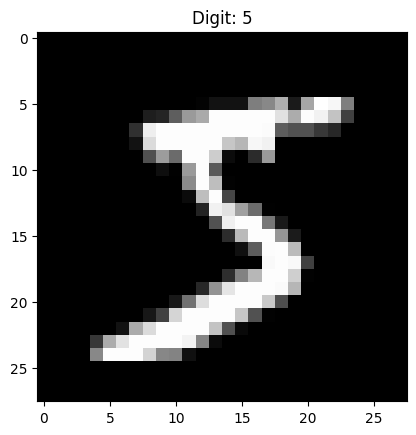

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9243 - loss: 0.2649 - val_accuracy: 0.9558 - val_loss: 0.1485
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9649 - loss: 0.1181 - val_accuracy: 0.9683 - val_loss: 0.1002
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9754 - loss: 0.0805 - val_accuracy: 0.9706 - val_loss: 0.0894
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9825 - loss: 0.0594 - val_accuracy: 0.9712 - val_loss: 0.0857
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9864 - loss: 0.0452 - val_accuracy: 0.9767 - val_loss: 0.0803


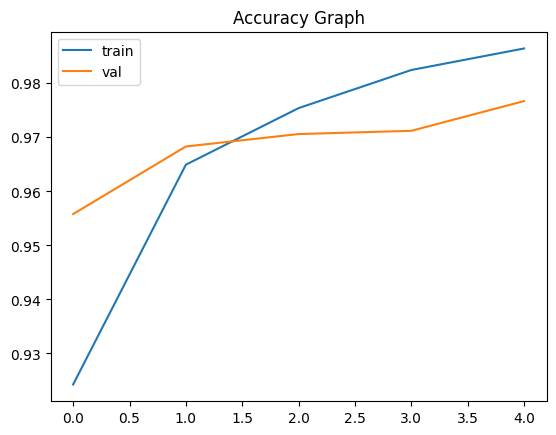

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9767 - loss: 0.0803
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


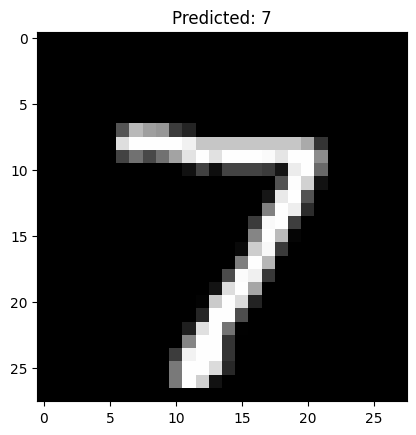

In [9]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Load Data
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
x_train, x_test = x_train/255.0, x_test/255.0

# Show sample
plt.imshow(x_train[0], cmap='gray')
plt.title("Digit: " + str(y_train[0]))
plt.show()

# Model (MLP)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test,y_test))

# Graph 📊
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy Graph")
plt.legend()
plt.show()

# Evaluate
model.evaluate(x_test, y_test)

# Prediction
pred = model.predict(x_test)
plt.imshow(x_test[0], cmap='gray')
plt.title("Predicted: " + str(np.argmax(pred[0])))
plt.show()